# Glacial Lake Segmentation — Fast Colab Training

Fresh Colab + T4 GPU notebook for DeepLabV3+ training.

**Workflow:** Google Drive dataset → one-time local Colab copy → local SSD DataLoader → T4 mixed precision training → checkpoints/logs saved back to Drive.

Before running: **Runtime → Change runtime type → T4 GPU**, then **Run all**.

In [1]:
# 1. GPU check
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU. Select a T4 GPU in Runtime → Change runtime type.")

print("GPU:", torch.cuda.get_device_name(0))
print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
torch.backends.cudnn.benchmark = True

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [2]:
# 2. Mount Drive
from google.colab import drive
drive.mount("/content/drive")
print("Drive mounted.")

Mounted at /content/drive
Drive mounted.


In [3]:
# 3. Clone repository
from pathlib import Path

%cd /content
REPO_DIR = Path("/content/glacial-lake-segmentation")

if not REPO_DIR.exists():
    !git clone -q https://github.com/ShubhamSnSharma/glacial-lake-segmentation.git

%cd /content/glacial-lake-segmentation
!git pull -q
!git log -1 --oneline

/content
/content/glacial-lake-segmentation
48d89e7 (HEAD -> main, origin/main, origin/HEAD) Add resumable Drive-safe training


In [4]:
# 4. Install lightweight dependencies only; keep Colab's CUDA PyTorch
!pip install -q pillow pyyaml matplotlib tqdm scikit-learn pandas

import torch
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA: True
GPU: Tesla T4


In [5]:
from pathlib import Path

# Shared Google Drive folder
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Glacial_Lake_Segmentation"
)

# Dataset folders are directly inside the root
DRIVE_DATA = DRIVE_ROOT

# Local Colab SSD
PROJECT_ROOT = Path("/content/glacial-lake-segmentation")
LOCAL_DATA = PROJECT_ROOT / "data" / "raw"

# Previous training outputs
DRIVE_TRAINING = DRIVE_ROOT / "training" / "deeplabv3plus_fast"
DRIVE_CHECKPOINTS = DRIVE_TRAINING / "checkpoints"
DRIVE_RESULTS = DRIVE_TRAINING / "results"

print("Drive dataset:", DRIVE_DATA)
print("Local dataset:", LOCAL_DATA)
print("Training output:", DRIVE_TRAINING)

Drive dataset: /content/drive/MyDrive/Glacial_Lake_Segmentation
Local dataset: /content/glacial-lake-segmentation/data/raw
Training output: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast


In [6]:
# 6. Verify Drive dataset
required = [
    DRIVE_DATA / "GLID" / "images",
    DRIVE_DATA / "GLID" / "labels",
    DRIVE_DATA / "val" / "images",
    DRIVE_DATA / "val" / "labels",
]

for p in required:
    print(p, "->", p.exists())

if not all(p.exists() for p in required):
    raise FileNotFoundError("Expected GLID/val dataset folders were not found in Drive.")

/content/drive/MyDrive/Glacial_Lake_Segmentation/GLID/images -> True
/content/drive/MyDrive/Glacial_Lake_Segmentation/GLID/labels -> True
/content/drive/MyDrive/Glacial_Lake_Segmentation/val/images -> True
/content/drive/MyDrive/Glacial_Lake_Segmentation/val/labels -> True


In [7]:
# 7. One-time Drive → local SSD dataset copy
import shutil, time

if LOCAL_DATA.exists() and (LOCAL_DATA / "GLID" / "images").exists():
    print("Local dataset already exists. Skipping copy.")
else:
    print("Copying dataset to local Colab storage...")
    start = time.time()
    LOCAL_DATA.parent.mkdir(parents=True, exist_ok=True)
    shutil.copytree(DRIVE_DATA, LOCAL_DATA)
    print(f"Copy complete: {(time.time()-start)/60:.1f} minutes")

Copying dataset to local Colab storage...
Copy complete: 35.7 minutes


In [8]:
import re

def valid_png_count(path):
    return sum(
        1
        for p in path.iterdir()
        if p.is_file()
        and p.suffix.lower() == ".png"
        and not p.name.startswith(".")
        and not re.search(r"\s*\(\d+\)$", p.stem)
    )

counts = [
    valid_png_count(LOCAL_DATA / "GLID" / "images"),
    valid_png_count(LOCAL_DATA / "GLID" / "labels"),
    valid_png_count(LOCAL_DATA / "val" / "images"),
    valid_png_count(LOCAL_DATA / "val" / "labels"),
]

print("Train images, train labels, val images, val labels:", counts)

if counts != [16000, 16000, 2367, 2367]:
    raise RuntimeError(f"Dataset count mismatch: {counts}")

print("LOCAL DATASET VERIFIED")

Train images, train labels, val images, val labels: [16000, 16000, 2367, 2367]
LOCAL DATASET VERIFIED


In [9]:
# 9. Dataset + DataLoaders

import sys
import torch
from torch.utils.data import DataLoader

# Ensure project root is accessible
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset import GLIDDataset

# Dataset directories
TRAIN_DIR = LOCAL_DATA / "GLID"
VAL_DIR = LOCAL_DATA / "val"

# Load datasets
train_ds = GLIDDataset(
    str(TRAIN_DIR),
    is_train=True,
    split="train"
)

val_ds = GLIDDataset(
    str(VAL_DIR),
    is_train=False,
    split="val"
)

# Memory-efficient settings for Colab T4
BATCH_SIZE = 4
NUM_WORKERS = 2

PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

# Training DataLoader
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
    drop_last=True,
)

# Validation DataLoader
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

# Display dataset information
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Batch size:", BATCH_SIZE)
print("DataLoader workers:", NUM_WORKERS)
print("Pin memory:", PIN_MEMORY)

Train samples: 16000
Val samples: 2367
Train batches: 4000
Val batches: 592
Batch size: 4
DataLoader workers: 2
Pin memory: True


In [10]:

# 10. Real batch test

images, masks = next(iter(train_loader))

print("Images:", images.shape, images.dtype)
print("Masks:", masks.shape, masks.dtype)
print("Mask values:", torch.unique(masks))

# Verify shapes using the configured batch size
assert images.shape == (BATCH_SIZE, 3, 512, 512)
assert masks.shape == (BATCH_SIZE, 1, 512, 512)

assert images.dtype == torch.float32
assert masks.dtype == torch.float32

assert masks.min() >= 0
assert masks.max() <= 1

print("REAL DATA BATCH OK")

Images: torch.Size([4, 3, 512, 512]) torch.float32
Masks: torch.Size([4, 1, 512, 512]) torch.float32
Mask values: tensor([0., 1.])
REAL DATA BATCH OK


In [11]:
# 11. Build DeepLabV3+

from src.model import build_model

device = torch.device("cuda")

model_cfg = {
    "model": {
        "name": "deeplabv3plus",
        "pretrained": True,
        "num_classes": 1,
        "freeze_encoder": False,
        "aspp_dilations": [6, 12, 18],
    }
}

# Build model
model = build_model(model_cfg).to(device)
model = model.to(memory_format=torch.channels_last)

# Display parameter count
summary = model.get_parameter_summary()

print("Total parameters:", f"{summary['total_parameters']:,}")
print("Encoder:", f"{summary['encoder_parameters']:,}")
print("Decoder:", f"{summary['decoder_parameters']:,}")

# Forward pass using an actual batch
model.eval()

with torch.no_grad():
    x = images.to(
        device,
        non_blocking=True,
        memory_format=torch.channels_last
    )

    with torch.autocast(device_type="cuda", dtype=torch.float16):
        y = model(x)

print("Input:", x.shape)
print("Output:", y.shape)

# Verify output dimensions dynamically
assert y.shape == (BATCH_SIZE, 1, 512, 512)

print("FORWARD PASS OK")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 167MB/s]


Total parameters: 40,347,041
Encoder: 23,508,032
Decoder: 1,303,905
Input: torch.Size([4, 3, 512, 512])
Output: torch.Size([4, 1, 512, 512])
FORWARD PASS OK


In [12]:
import time
import torch
from src.losses import CombinedBCEDiceLoss

# Build a fresh model for the benchmark
bench_model = build_model(model_cfg).to(device)
bench_model = bench_model.to(memory_format=torch.channels_last)
bench_model.train()

bench_loss = CombinedBCEDiceLoss()
bench_opt = torch.optim.AdamW(
    bench_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
bench_scaler = torch.amp.GradScaler("cuda")

# Only benchmark two batches.
# Do NOT convert the entire DataLoader to a list.
times = []

for i, (batch_images, batch_masks) in enumerate(train_loader):
    if i >= 2:
        break

    start = time.time()

    batch_images = batch_images.to(
        device,
        non_blocking=True,
        memory_format=torch.channels_last
    )
    batch_masks = batch_masks.to(device, non_blocking=True)

    bench_opt.zero_grad(set_to_none=True)

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):
        logits = bench_model(batch_images)
        loss = bench_loss(logits, batch_masks)

    bench_scaler.scale(loss).backward()
    bench_scaler.unscale_(bench_opt)

    torch.nn.utils.clip_grad_norm_(
        bench_model.parameters(),
        1.0
    )

    bench_scaler.step(bench_opt)
    bench_scaler.update()

    torch.cuda.synchronize()
    times.append(time.time() - start)

    print(
        f"Benchmark batch {i + 1}/2 completed "
        f"| loss: {loss.item():.4f} "
        f"| time: {times[-1]:.2f}s"
    )

avg_time = sum(times) / len(times)

print(f"\nAverage time per batch: {avg_time:.2f}s")
print(
    "Estimated epoch time:",
    round(avg_time * len(train_loader) / 60, 1),
    "minutes"
)
print("Benchmark completed successfully.")

Benchmark batch 1/2 completed | loss: 10.1164 | time: 7.68s
Benchmark batch 2/2 completed | loss: 10.0789 | time: 0.24s

Average time per batch: 3.96s
Estimated epoch time: 264.3 minutes
Benchmark completed successfully.


In [13]:
# 13. Persistent output folders
for folder in [
    DRIVE_TRAINING,
    DRIVE_CHECKPOINTS,
    DRIVE_RESULTS,
    DRIVE_RESULTS / "logs",
    DRIVE_RESULTS / "predictions",
    DRIVE_RESULTS / "plots",
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Persistent output folders ready.")

Persistent output folders ready.


In [14]:
from pathlib import Path
import torch

# Checkpoint from the previous training session
CHECKPOINT_PATH = (
    DRIVE_CHECKPOINTS / "latest_amp_model.pth"
)

print("Checkpoint path:", CHECKPOINT_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(
        CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False
    )

    print("\nCheckpoint contents:")
    print(checkpoint.keys())

    print("\nSaved epoch:", checkpoint.get("epoch", "Not found"))
    print("Best validation F1:", checkpoint.get("best_val_f1", "Not found"))
else:
    print("\nCheckpoint not found. Do not start training yet.")

Checkpoint path: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/latest_amp_model.pth
Checkpoint exists: True

Checkpoint contents:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'scaler_state_dict', 'best_f1', 'best_epoch', 'history', 'batch_size', 'model_name', 'amp'])

Saved epoch: 19
Best validation F1: Not found


In [15]:
# 14. FAST + RESUMABLE TRAINING
#
# Saves after EVERY completed epoch to Drive.
# If Colab disconnects, reopen this notebook and Run all:
# the latest checkpoint is loaded and training continues from the next epoch.

import csv, math, time
from tqdm.auto import tqdm
from src.metrics import MetricTracker

EPOCHS = 30
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
WARMUP_EPOCHS = 5
PATIENCE = 7

LATEST = DRIVE_CHECKPOINTS / "latest_amp_model.pth"
BEST = DRIVE_CHECKPOINTS / "best_amp_model.pth"
HISTORY = DRIVE_RESULTS / "logs" / "fast_training_history.csv"

model = build_model(model_cfg).to(device)
model = model.to(memory_format=torch.channels_last)
criterion = CombinedBCEDiceLoss()

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scaler = torch.amp.GradScaler("cuda", enabled=True)

start_epoch = 1
best_f1 = -1.0
best_epoch = 0
history = []

if LATEST.exists():
    ckpt = torch.load(LATEST, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_f1 = ckpt.get("best_f1", -1.0)
    best_epoch = ckpt.get("best_epoch", 0)
    history = ckpt.get("history", [])
    print(f"RESUMING from epoch {start_epoch}; best F1={best_f1:.4f}")
else:
    print("Starting fresh from epoch 1.")

if not HISTORY.exists():
    with open(HISTORY, "w", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow([
            "epoch","train_loss","train_iou","train_f1",
            "train_precision","train_recall","val_loss","val_iou",
            "val_f1","val_precision","val_recall","val_accuracy",
            "learning_rate","epoch_time_sec"
        ])

def lr_for_epoch(e):
    if e < WARMUP_EPOCHS:
        return LEARNING_RATE * (0.1 + 0.9 * (e + 1) / WARMUP_EPOCHS)
    progress = (e - WARMUP_EPOCHS) / max(1, EPOCHS - WARMUP_EPOCHS)
    return 1e-6 + 0.5 * (LEARNING_RATE - 1e-6) * (1 + math.cos(math.pi * progress))

def set_lr(e):
    lr = lr_for_epoch(e)
    for g in optimizer.param_groups:
        g["lr"] = lr
    return lr

def save_ckpt(epoch, best=False):
    target = BEST if best else LATEST
    tmp = target.with_suffix(target.suffix + ".tmp")
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_f1": best_f1,
        "best_epoch": best_epoch,
        "history": history,
        "batch_size": BATCH_SIZE,
        "model_name": "deeplabv3plus",
        "amp": True,
    }, tmp)
    tmp.replace(target)

def train_epoch(epoch):
    model.train()
    tracker = MetricTracker(threshold=0.5)
    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]", dynamic_ncols=True)

    for imgs, msks in pbar:
        imgs = imgs.to(device, non_blocking=True, memory_format=torch.channels_last)
        msks = msks.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
            loss = criterion(logits, msks)

        if not torch.isfinite(loss):
            raise RuntimeError(f"Non-finite loss: {loss.item()}")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        m = tracker.update(logits.detach(), msks, loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}", f1=f"{m['f1']:.3f}", iou=f"{m['iou']:.3f}")

    return tracker.compute()

@torch.no_grad()
def validate(epoch):
    model.eval()
    tracker = MetricTracker(threshold=0.5)
    pbar = tqdm(val_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Val]", dynamic_ncols=True)

    for imgs, msks in pbar:
        imgs = imgs.to(device, non_blocking=True, memory_format=torch.channels_last)
        msks = msks.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
            loss = criterion(logits, msks)

        m = tracker.update(logits, msks, loss.item())
        pbar.set_postfix(loss=f"{loss.item():.4f}", f1=f"{m['f1']:.3f}", iou=f"{m['iou']:.3f}")

    return tracker.compute()

no_improvement = 0

print("=" * 70)
print("FAST DEEPLABV3+ TRAINING")
print("=" * 70)
print("GPU:", torch.cuda.get_device_name(0))
print("Batch:", BATCH_SIZE)
print("AMP: True")
print("Epochs:", EPOCHS)
print("Starting epoch:", start_epoch)
print("=" * 70)

for epoch in range(start_epoch, EPOCHS + 1):
    t0 = time.time()
    lr = set_lr(epoch - 1)

    tr = train_epoch(epoch)
    va = validate(epoch)

    elapsed = time.time() - t0
    is_best = va["f1"] > best_f1

    if is_best:
        best_f1 = va["f1"]
        best_epoch = epoch
        no_improvement = 0
    else:
        no_improvement += 1

    row = {
        "epoch": epoch,
        "train_loss": tr["loss"], "train_iou": tr["iou"], "train_f1": tr["f1"],
        "train_precision": tr["precision"], "train_recall": tr["recall"],
        "val_loss": va["loss"], "val_iou": va["iou"], "val_f1": va["f1"],
        "val_precision": va["precision"], "val_recall": va["recall"],
        "val_accuracy": va["accuracy"], "learning_rate": lr,
        "epoch_time_sec": elapsed,
    }
    history.append(row)

    with open(HISTORY, "a", newline="", encoding="utf-8") as f:
        csv.writer(f).writerow(row.values())

    save_ckpt(epoch, best=False)
    if is_best:
        save_ckpt(epoch, best=True)

    print("\n" + "=" * 70)
    print(f"Epoch {epoch}/{EPOCHS}")
    print(f"Train loss: {tr['loss']:.4f} | Train F1: {tr['f1']:.4f}")
    print(f"Val loss:   {va['loss']:.4f} | Val F1:   {va['f1']:.4f}")
    print(f"Val IoU: {va['iou']:.4f} | Precision: {va['precision']:.4f} | Recall: {va['recall']:.4f}")
    print(f"Epoch time: {elapsed/60:.2f} min")
    print(f"Best F1: {best_f1:.4f} (epoch {best_epoch})")
    print(f"Checkpoint: {LATEST}")
    print("=" * 70)

    if no_improvement >= PATIENCE:
        print(f"Early stopping after {PATIENCE} epochs without validation F1 improvement.")
        break

print("\nTRAINING FINISHED")
print("Best F1:", best_f1)
print("Best epoch:", best_epoch)
print("Best checkpoint:", BEST)
print("Latest checkpoint:", LATEST)
print("History:", HISTORY)

RESUMING from epoch 20; best F1=0.9212
FAST DEEPLABV3+ TRAINING
GPU: Tesla T4
Batch: 4
AMP: True
Epochs: 30
Starting epoch: 20


Epoch 20/30 [Train]:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch 20/30 [Val]:   0%|          | 0/592 [00:00<?, ?it/s]


Epoch 20/30
Train loss: 0.0627 | Train F1: 0.9554
Val loss:   0.0912 | Val F1:   0.9209
Val IoU: 0.8534 | Precision: 0.9277 | Recall: 0.9142
Epoch time: 11.72 min
Best F1: 0.9212 (epoch 16)
Checkpoint: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/latest_amp_model.pth


Epoch 21/30 [Train]:   0%|          | 0/4000 [00:00<?, ?it/s]

...

Epoch 29/30 [Val]:   0%|          | 0/592 [00:00<?, ?it/s]


Epoch 29/30
Train loss: 0.0508 | Train F1: 0.9642
Val loss:   0.0791 | Val F1:   0.9392
Val IoU: 0.8853 | Precision: 0.9476 | Recall: 0.9309
Epoch time: 11.93 min
Best F1: 0.9397 (epoch 26)
Checkpoint: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/latest_amp_model.pth


Epoch 30/30 [Train]:   0%|          | 0/4000 [00:00<?, ?it/s]

Epoch 30/30 [Val]:   0%|          | 0/592 [00:00<?, ?it/s]


Epoch 30/30
Train loss: 0.0505 | Train F1: 0.9642
Val loss:   0.0803 | Val F1:   0.9393
Val IoU: 0.8856 | Precision: 0.9510 | Recall: 0.9279
Epoch time: 11.98 min
Best F1: 0.9397 (epoch 26)
Checkpoint: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/latest_amp_model.pth

TRAINING FINISHED
Best F1: 0.9396720886571736
Best epoch: 26
Best checkpoint: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/best_amp_model.pth
Latest checkpoint: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/latest_amp_model.pth
History: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/results/logs/fast_training_history.csv


In [16]:
# 15. Result summary
import pandas as pd

if HISTORY.exists():
    df = pd.read_csv(HISTORY)
    display(df.tail(10))
    best = df.loc[df["val_f1"].idxmax()]
    print("\nBEST RESULT")
    print("Epoch:", int(best["epoch"]))
    print("Val F1:", round(best["val_f1"], 4))
    print("Val IoU:", round(best["val_iou"], 4))
    print("Precision:", round(best["val_precision"], 4))
    print("Recall:", round(best["val_recall"], 4))
else:
    print("No history file found.")

,epoch,train_loss,train_iou,train_f1,train_precision,train_recall,val_loss,val_iou,val_f1,val_precision,val_recall,val_accuracy,learning_rate,epoch_time_sec
20,21,0.060068,0.918516,0.957528,0.959059,0.956001,0.089878,0.870020,0.930493,0.957141,0.905289,0.996907,0.000035,710.207752
21,22,0.057908,0.921604,0.959203,0.960809,0.957602,0.085455,0.883871,0.938356,0.952960,0.924193,0.997223,0.000029,722.182308
22,23,0.056323,0.922939,0.959926,0.962003,0.957857,0.087146,0.873583,0.932527,0.948390,0.917185,0.996965,0.000024,724.754389
23,24,0.054726,0.925657,0.961393,0.962224,0.960564,0.083770,0.879862,0.936092,0.945758,0.926621,0.997106,0.000019,720.552150
24,25,0.053620,0.927210,0.962230,0.963622,0.960842,0.082872,0.882510,0.937589,0.949742,0.925743,0.997181,0.000014,720.869904
25,26,0.052517,0.928707,0.963036,0.964282,0.961792,0.082451,0.886209,0.939672,0.956100,0.923800,0.997287,0.000010,723.627850
26,27,0.051963,0.929670,0.963553,0.964792,0.962318,0.082924,0.882993,0.937861,0.954719,0.921589,0.997207,0.000007,721.183469
27,28,0.051413,0.930600,0.964053,0.964953,0.963154,0.081129,0.884966,0.938973,0.951335,0.926928,0.997244,0.000004,713.158329
28,29,0.050779,0.930898,0.964212,0.965363,0.963064,0.079100,0.885338,0.939182,0.947643,0.930871,0.997243,0.000003,716.002332
29,30,0.050504,0.930844,0.964184,0.964871,0.963497,0.080284,0.885565,0.939310,0.951042,0.927864,0.997258,0.000001,718.838290



BEST RESULT
Epoch: 26
Val F1: 0.9397
Val IoU: 0.8862
Precision: 0.9561
Recall: 0.9238


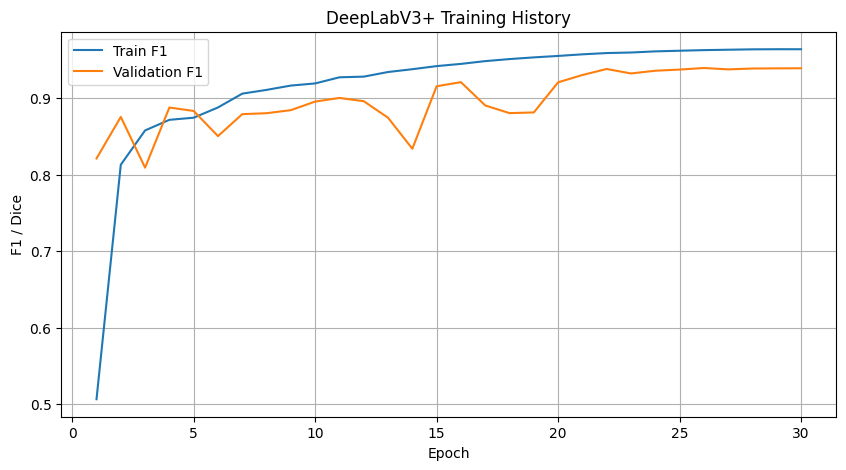

Saved: /content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/results/plots/training_f1.png


In [17]:
# 16. Optional training plot
import matplotlib.pyplot as plt
import pandas as pd

if HISTORY.exists():
    df = pd.read_csv(HISTORY)

    plt.figure(figsize=(10, 5))
    plt.plot(df["epoch"], df["train_f1"], label="Train F1")
    plt.plot(df["epoch"], df["val_f1"], label="Validation F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 / Dice")
    plt.title("DeepLabV3+ Training History")
    plt.grid(True)
    plt.legend()

    plot_path = DRIVE_RESULTS / "plots" / "training_f1.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", plot_path)
else:
    print("No training history available.")

In [18]:
# ============================================================
# 17. LOAD BEST DEEPLABV3+ CHECKPOINT
# ============================================================

import torch
from pathlib import Path

BEST_CHECKPOINT = (
    DRIVE_TRAINING
    / "checkpoints"
    / "best_amp_model.pth"
)

print("Loading best checkpoint:")
print(BEST_CHECKPOINT)
print("Exists:", BEST_CHECKPOINT.exists())

# Build a fresh model
best_model = build_model({
    "model": {
        "name": "deeplabv3plus",
        "pretrained": True,
        "num_classes": 1,
        "freeze_encoder": False,
        "aspp_dilations": [6, 12, 18],
    }
})

best_model = best_model.to(device)

# Load best weights
checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=device,
    weights_only=False
)

best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

print("\n" + "=" * 60)
print("BEST MODEL LOADED")
print("=" * 60)
print("Epoch:", checkpoint["epoch"])
print("Best F1:", checkpoint["best_f1"])
print("Model:", checkpoint["model_name"])
print("AMP:", checkpoint["amp"])
print("=" * 60)

Loading best checkpoint:
/content/drive/MyDrive/Glacial_Lake_Segmentation/training/deeplabv3plus_fast/checkpoints/best_amp_model.pth
Exists: True

BEST MODEL LOADED
Epoch: 26
Best F1: 0.9396720886571736
Model: deeplabv3plus
AMP: True


In [20]:
# ============================================================
# 18. FINAL VALIDATION EVALUATION
# ============================================================

from tqdm.auto import tqdm

criterion = CombinedBCEDiceLoss()

tracker = MetricTracker()

total_loss = 0.0
num_batches = 0

best_model.eval()

with torch.no_grad():

    for images, masks in tqdm(
        val_loader,
        desc="Final Validation"
    ):

        images = images.to(
            device,
            non_blocking=True
        ).contiguous(memory_format=torch.channels_last)

        masks = masks.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            logits = best_model(images)

            loss = criterion(
                logits,
                masks
            )

        total_loss += loss.item()
        num_batches += 1

        tracker.update(logits, masks)

metrics = tracker.compute()

final_val_loss = total_loss / num_batches

print("\n" + "=" * 70)
print("FINAL VALIDATION RESULTS — BEST CHECKPOINT")
print("=" * 70)

print(f"Checkpoint epoch : {checkpoint['epoch']}")
print(f"Loss             : {final_val_loss:.4f}")
print(f"F1 / Dice        : {metrics['f1']:.4f} ({metrics['f1']*100:.2f}%)")
print(f"IoU              : {metrics['iou']:.4f} ({metrics['iou']*100:.2f}%)")
print(f"Precision        : {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
print(f"Recall           : {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
print(f"Accuracy         : {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print("=" * 70)

Final Validation:   0%|          | 0/592 [00:00<?, ?it/s]


FINAL VALIDATION RESULTS — BEST CHECKPOINT
Checkpoint epoch : 26
Loss             : 0.0825
F1 / Dice        : 0.9397 (93.97%)
IoU              : 0.8862 (88.62%)
Precision        : 0.9561 (95.61%)
Recall           : 0.9238 (92.38%)
Accuracy         : 0.9973 (99.73%)
